# Test de `read_fueldb` y `compute_pyrolysis_dH`

Módulos: `src.io.fuels_reader` · `src.physics.reactions.pyrolysis`  
Formato de entrada: `materials/fuels/<id>.yaml`

## Secciones del `fuel_config` devuelto

| Sección | Tipo | Descripción |
|---|---|---|
| `fuel_id` | str | Identificador del combustible |
| `description` | str | Descripción libre |
| `source` | str | Referencia bibliográfica |
| `physical` | dict | `rho_particle` [kg/m³], `dp_initial` [m] |
| `heating_values` | dict | LHV biomass/char/tar [J/kg] |
| `thermal` | dict | Cp callables y k para biomass, char, moisture |
| `char_composition` | dict | α, β, MW_per_C (fórmula CHαOβ) |
| `tar` | dict | a, b, c, MW, Cp_fn, µ_ref, k_ref, σLJ, ε/k_B |
| `pyrolysis_yields` | dict | Fracción másica de cada producto (suma = 1) |
| `kinetics` | dict | A [1/s o m/s] y E [J/mol] para 5 reacciones |
| `co_co2_ratio` | dict | Ratio CO/CO2 en oxidación del char (modelo Anca-Couce) |

## Combustible de referencia

| Campo | Valor |
|---|---|
| ID | `softwood_spruce` |
| Fuente | Anca-Couce et al., *Fuel* 296 (2021) 120687 |
| Esquema de pirólisis | RAC (*Refined Alkali Cellulose*) |

---

## Tests realizados

1. **Carga y validación** — `read_fueldb` devuelve un dict completo y validado con todas las secciones requeridas.
2. **Propiedades físicas y caloríficas** — identidad del combustible, densidad, tamaño de partícula y LHV.
3. **Yields de pirólisis** — tabla de fracciones másicas por especie, verificación suma = 1, gráfico de barras.
4. **Cinéticas de reacción** — 5 reacciones: A, E, temperatura de semivida T₅₀ (t_ref = 1 s).
5. **Entalpía de pirólisis** — `compute_pyrolysis_dH`: cálculo paso a paso y desglose energético.
6. **Propiedades térmicas del sólido** — callables Cp(T) para biomass, char y moisture en rejilla 300–1200 K.


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.io.fuels_reader import read_fueldb
from src.physics.reactions.pyrolysis import compute_pyrolysis_dH

FUEL_PATH = os.path.join(ROOT, "materials", "fuels", "softwood_spruce.yaml")
R_GAS = 8.31446261815324   # J/mol/K

print("Import OK")
print("FUEL_PATH:", FUEL_PATH)
print("Existe YAML:", os.path.isfile(FUEL_PATH))


Import OK
FUEL_PATH: C:\Users\MiguelCamaraSanz\OneDrive - Fundacion CIRCE\GITHUB\GasifierSimNet\materials\fuels\softwood_spruce.yaml
Existe YAML: True


## TEST 1 — Carga y validación básica

`read_fueldb` lee el YAML, valida todos los campos obligatorios y construye
los callables `Cp_fn(T)` para cada fase sólida. Devuelve un dict con 11 secciones.
El test verifica que todas las secciones requeridas están presentes y que los
campos de rango físico son positivos.


In [2]:
fc = read_fueldb(FUEL_PATH)

REQUIRED = ["fuel_id","description","source","physical","heating_values",
            "thermal","char_composition","tar","pyrolysis_yields","kinetics","co_co2_ratio"]

print(f"fuel_id   : {fc['fuel_id']}")
print(f"source    : {fc['source']}")
print(f"Secciones : {list(fc.keys())}")

for key in REQUIRED:
    assert key in fc, f"Falta seccion '{key}'"

# Verificaciones fisicas minimas
assert fc["physical"]["rho_particle"] > 0, "rho_particle debe ser > 0"
assert fc["physical"]["dp_initial"]   > 0, "dp_initial debe ser > 0"
for sp, hv in fc["heating_values"].items():
    assert hv > 0, f"heating_values[{sp}] debe ser > 0"
total_yield = sum(fc["pyrolysis_yields"].values())
assert abs(total_yield - 1.0) < 1e-3, f"Yields no suman 1: {total_yield:.6f}"

# Verificar callables termicos
for solid in ("biomass", "char", "moisture"):
    Cp_fn = fc["thermal"][solid]["Cp_fn"]
    assert callable(Cp_fn), f"thermal[{solid}]['Cp_fn'] debe ser callable"
    val = float(Cp_fn(500.0))
    assert val > 0, f"Cp({solid}, 500K) debe ser > 0, got {val}"

print(f"\nVerificacion OK — {len(REQUIRED)} secciones presentes, yields suman {total_yield:.6f}")


fuel_id   : softwood_spruce
source    : Anca-Couce et al., Fuel 296 (2021) 120687
Secciones : ['fuel_id', 'description', 'source', 'physical', 'heating_values', 'thermal', 'char_composition', 'tar', 'pyrolysis_yields', 'kinetics', 'co_co2_ratio']

Verificacion OK — 11 secciones presentes, yields suman 1.000000


## TEST 2 — Propiedades físicas y caloríficas

Muestra las propiedades físicas de la partícula y los poderes caloríficos inferiores (LHV)
de las tres fases que intervienen en el balance energético del gasificador.
Los LHV se almacenan internamente en J/kg (convertidos desde MJ/kg por `read_fueldb`).


In [3]:
pd.set_option("display.float_format", "{:.5g}".format)

# Identificacion
print(f"fuel_id    : {fc['fuel_id']}")
print(f"descripcion: {fc['description']}")
print(f"fuente     : {fc['source']}")

# Propiedades fisicas de la particula
df_phys = pd.DataFrame([
    {"Propiedad": "rho_particle [kg/m3]",       "Valor": fc["physical"]["rho_particle"]},
    {"Propiedad": "dp_initial [m]",             "Valor": fc["physical"]["dp_initial"]},
    {"Propiedad": "dp_initial [mm]",            "Valor": fc["physical"]["dp_initial"]*1e3},
]).set_index("Propiedad")
print("\n=== Particula ===")
display(df_phys)

# Poderes calorificos
df_hv = pd.DataFrame([
    {"Fase": sp, "LHV [J/kg]": hv, "LHV [MJ/kg]": hv/1e6}
    for sp, hv in fc["heating_values"].items()
]).set_index("Fase")
print("\n=== Poderes calorificos inferiores (LHV) ===")
display(df_hv)

# Composicion del char (formula CHαOβ)
cc = fc["char_composition"]
print(f"\n=== Composicion del char (CHaOb) ===")
print(f"  alpha   = {cc['alpha']:.4f}  (mol H por mol C)")
print(f"  beta    = {cc['beta']:.4f}   (mol O por mol C)")
print(f"  MW/C    = {cc['MW_per_C']*1e3:.4f} g/mol")
print(f"  Formula: CH{cc['alpha']:.2f}O{cc['beta']:.4f}")


fuel_id    : softwood_spruce
descripcion: Softwood (spruce) for fixed-bed updraft gasification
fuente     : Anca-Couce et al., Fuel 296 (2021) 120687

=== Particula ===


,Valor
Propiedad,
rho_particle [kg/m3],430
dp_initial [m],0.01
dp_initial [mm],10



=== Poderes calorificos inferiores (LHV) ===


,LHV [J/kg],LHV [MJ/kg]
Fase,,
biomass,1.913e+07,19.13
char,3.237e+07,32.37
tar,2.144e+07,21.44



=== Composicion del char (CHaOb) ===
  alpha   = 0.3934  (mol H por mol C)
  beta    = 0.0484   (mol O por mol C)
  MW/C    = 13.1700 g/mol
  Formula: CH0.39O0.0484


## TEST 3 — Yields de pirólisis

La pirólisis primaria transforma la biomasa seca en char y 7 productos volátiles.
Las fracciones másicas se obtienen del esquema RAC aplicado a madera blanda.
La verificación `suma = 1` es crítica: un error aquí se propagaría directamente
a todos los balances de masa del gasificador.


,Fase,Yield [-],Yield [%]
Especie,,,
char,solido,0.234,23.4
CO,gas,0.082,8.2
H2O,gas,0.114,11.4
CO2,gas,0.124,12.4
H2,gas,0.006,0.6
CH4,gas,0.016,1.6
C2H4,gas,0.013,1.3
tar,condensable,0.411,41.1



Suma de yields: 1.000000   (error vs 1.0: 0.0000%)


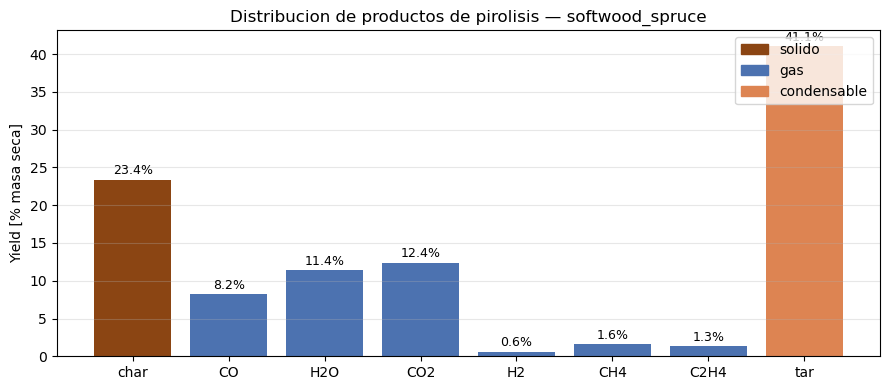

In [4]:
yields = fc["pyrolysis_yields"]

df_y = pd.DataFrame([
    {"Especie": sp, "Yield [-]": y, "Yield [%]": y*100}
    for sp, y in yields.items()
])
df_y["Fase"] = df_y["Especie"].map(
    {"char":"solido","CO":"gas","H2O":"gas","CO2":"gas",
     "H2":"gas","CH4":"gas","C2H4":"gas","tar":"condensable"}
)
df_y = df_y.set_index("Especie")
display(df_y[["Fase","Yield [-]","Yield [%]"]])

total = sum(yields.values())
print(f"\nSuma de yields: {total:.6f}   (error vs 1.0: {abs(total-1)*100:.4f}%)")
assert abs(total - 1.0) < 1e-3

# Grafico de barras
fig, ax = plt.subplots(figsize=(9, 4))
colors = {"solido":"#8B4513","gas":"#4C72B0","condensable":"#DD8452"}
bar_colors = [colors[df_y.loc[sp,"Fase"]] for sp in df_y.index]
ax.bar(df_y.index, df_y["Yield [%]"], color=bar_colors)
for i, (sp, row) in enumerate(df_y.iterrows()):
    ax.text(i, row["Yield [%]"]+0.3, f"{row['Yield [%]']:.1f}%",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Yield [% masa seca]")
ax.set_title(f"Distribucion de productos de pirolisis — {fc['fuel_id']}")
ax.legend(handles=[plt.Rectangle((0,0),1,1,color=v,label=k) for k,v in colors.items()],
          loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## TEST 4 — Cinéticas de reacción

Las 5 reacciones del modelo siguen la ley de Arrhenius `k = A·exp(-E/RT)`.
La temperatura de semivida `T₅₀` es la temperatura a la que la tasa con
unidad de densidad tiene semivida de 1 s: `T₅₀ = E / [R·ln(A/ln2)]`.
Da una referencia rápida del rango de activación de cada reacción.


In [5]:
import math

def T50(A, E):
    """Temperatura de semivida para t_ref = 1 s."""
    return E / (R_GAS * math.log(A / math.log(2)))

kin = fc["kinetics"]
rows = []
for rxn, params in kin.items():
    A, E = params["A"], params["E"]
    T50_K = T50(A, E)
    rows.append({
        "Reaccion":   rxn,
        "A [1/s|m/s]":  A,
        "E [kJ/mol]":   E/1e3,
        "E/R [K]":      E/R_GAS,
        "T50 [K]":      round(T50_K, 1),
        "T50 [C]":      round(T50_K - 273.15, 1),
    })

df4 = pd.DataFrame(rows).set_index("Reaccion")
pd.set_option("display.float_format", "{:.4g}".format)
display(df4)

# Ratio CO/CO2
r = fc["co_co2_ratio"]
print(f"\nRatio CO/CO2 (Anca-Couce 2017):")
print(f"  modelo : {r['model']}")
print(f"  C1={r['C1']:.1f}, C2={r['C2']:.0f} K")
T_test_vals = [900, 1000, 1100, 1200]
for T in T_test_vals:
    eta = r["C1"] * math.exp(-r["C2"]/T) / (1 + r["C1"] * math.exp(-r["C2"]/T))
    print(f"  eta(T={T} K) = {eta:.3f}  => CO:{eta:.2%}  CO2:{1-eta:.2%}")


,A [1/s|m/s],E [kJ/mol],E/R [K],T50 [K],T50 [C]
Reaccion,,,,,
drying,5.6e+06,88,1.058e+04,665.5,392.3
pyrolysis,2e+08,133,1.6e+04,821.1,548
char_oxidation,5.7e+07,160,1.924e+04,1056,782.7
char_CO2_gasification,1e+07,220,2.646e+04,1605,1332
char_H2O_gasification,1e+07,220,2.646e+04,1605,1332



Ratio CO/CO2 (Anca-Couce 2017):
  modelo : anca_couce_2017
  C1=12.0, C2=3300 K
  eta(T=900 K) = 0.235  => CO:23.47%  CO2:76.53%
  eta(T=1000 K) = 0.307  => CO:30.68%  CO2:69.32%
  eta(T=1100 K) = 0.374  => CO:37.40%  CO2:62.60%
  eta(T=1200 K) = 0.434  => CO:43.41%  CO2:56.59%


## TEST 5 — Entalpía de pirólisis (`compute_pyrolysis_dH`)

La entalpía de pirólisis representa el calor neto absorbido por el sólido
durante la conversión de biomasa en char + volátiles. Se calcula como:

$$\Delta H_{pyr} = LHV_{bio} - (y_{char} \cdot LHV_{char} + y_{tar} \cdot LHV_{tar})$$

> Un valor positivo significa que la reacción es endotérmica: consume calor del sólido.
> Los gases permanentes (CO, CO2, H2, CH4, C2H4, H2O) no se incluyen en la diferencia
> porque su entalpía de combustión ya está implícita en los balances de la fase gas.


In [6]:
hv  = fc["heating_values"]
yld = fc["pyrolysis_yields"]

dH_pyr = compute_pyrolysis_dH(
    heating_values=hv,
    yields=yld,
)

# Desglose
y_char = yld["char"]
y_tar  = yld["tar"]
calor_productos = y_char * hv["char"] + y_tar * hv["tar"]
calor_reactivo  = hv["biomass"]

df5 = pd.DataFrame([
    {"Termino":             "LHV biomasa",           "Valor [J/kg]": calor_reactivo},
    {"Termino":             "y_char * LHV_char",     "Valor [J/kg]": y_char*hv["char"]},
    {"Termino":             "y_tar  * LHV_tar",      "Valor [J/kg]": y_tar*hv["tar"]},
    {"Termino":             "Suma productos (char+tar)","Valor [J/kg]": calor_productos},
    {"Termino":             "dH_pyr = LHV_bio - suma","Valor [J/kg]": dH_pyr},
]).set_index("Termino")
display(df5)

signo = "endotermica" if dH_pyr > 0 else "exotermica"
print(f"\ndH_pyr = {dH_pyr/1e6:.4f} MJ/kg_biomasa  ({signo})")
assert dH_pyr > 0, "La pirolisis de madera blanda debe ser endotermica"
print("Verificacion OK — pirolisis endotermica como se espera para madera blanda")


,Valor [J/kg]
Termino,
LHV biomasa,1.913e+07
y_char * LHV_char,7.575e+06
y_tar * LHV_tar,8.812e+06
Suma productos (char+tar),1.639e+07
dH_pyr = LHV_bio - suma,2.744e+06



dH_pyr = 2.7436 MJ/kg_biomasa  (endotermica)
Verificacion OK — pirolisis endotermica como se espera para madera blanda


## TEST 6 — Propiedades térmicas del sólido

Las tres fases sólidas (biomasa, char, humedad) tienen callables `Cp_fn(T)` [J/kg·K]
y conductividad térmica `k` [W/m·K] constante. En el RHS del gasificador estas
propiedades alimentan el balance de energía del sólido.

El callable acepta arrays de numpy (evalúa todos los nodos de la malla en una llamada).


Cp [J/kg*K]  k [W/m*K]
Fase     T [K]                        
biomass  300           1800       0.17
         400           1900       0.17
         500           2000       0.17
         600           2100       0.17
         700           2200       0.17
         800           2300       0.17
         900           2400       0.17
         1000          2500       0.17
         1100          2600       0.17
         1200          2700       0.17
char     300          985.4        0.1
         400           1146        0.1
         500           1294        0.1
         600           1427        0.1
         700           1547        0.1
         800           1654        0.1
         900           1746        0.1
         1000          1825        0.1
         1100          1890        0.1
         1200          1942        0.1
moisture 300           4200        0.6
         400           4200        0.6
         500           4200        0.6
         600           4200        0.6
         700           4200        0.6
         800           4200        0.6
         900           4200        0.6
         1000          4200        0.6
         1100          4200        0.6
         1200          4200        0.6

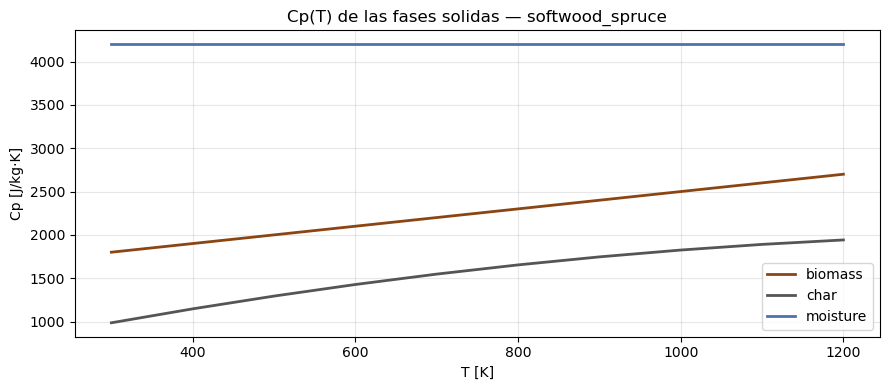

Verificacion OK — Cp > 0 en todo [300, 1200] K para las tres fases


In [7]:
T_grid = np.linspace(300.0, 1200.0, 10)   # K

records = []
for solid in ("biomass", "char", "moisture"):
    th = fc["thermal"][solid]
    Cp_arr = th["Cp_fn"](T_grid)
    for T, Cp in zip(T_grid, Cp_arr):
        records.append({"Fase": solid, "T [K]": round(float(T),1),
                        "Cp [J/kg*K]": float(Cp), "k [W/m*K]": th["k"]})

df6 = pd.DataFrame(records).set_index(["Fase","T [K]"])
pd.set_option("display.float_format", "{:.4g}".format)
display(df6)

# Grafico Cp(T) para las tres fases
fig, ax = plt.subplots(figsize=(9, 4))
for solid, color in [("biomass","#8B4513"),("char","#555555"),("moisture","#4C72B0")]:
    Cp_arr = fc["thermal"][solid]["Cp_fn"](T_grid)
    ax.plot(T_grid, Cp_arr, label=solid, color=color, lw=2)
ax.set_xlabel("T [K]")
ax.set_ylabel("Cp [J/kg·K]")
ax.set_title(f"Cp(T) de las fases solidas — {fc['fuel_id']}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Verificacion: Cp debe ser positivo en todo el rango
for solid in ("biomass","char","moisture"):
    Cp_check = fc["thermal"][solid]["Cp_fn"](T_grid)
    assert np.all(Cp_check > 0), f"Cp({solid}) contiene valores no positivos"
print("Verificacion OK — Cp > 0 en todo [300, 1200] K para las tres fases")
